# Multi-Omics EDA v2 — mRNA + CNV + Mutation + DNA Methylation
### Research-grade preprocessing for 4 modalities
- **New**: DNA Methylation (27K probes, beta values [0,1])
- **Methylation missing values**: probe-wise median imputation (NOT 0 — that means fully unmethylated)
- **Dynamic**: config flag `INCLUDE_METHYLATION` to easily toggle methylation on/off


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_theme(style='whitegrid')

def section(title):
    print('\n' + '='*65)
    print(f'  {title}')
    print('='*65)

# ═══════════════════════════════════════════════════════
#  PATHS — adjust for your Kaggle dataset
# ═══════════════════════════════════════════════════════
path_mrna  = '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-data/EBAdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena'
path_cnv   = '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-data/Gistic2_CopyNumber_Gistic2_all_thresholded.by_genes'
path_mut   = '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-data/mc3.v0.2.8.PUBLIC.nonsilentGene.xena'
path_pheno = '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-data/TCGA_phenotype_denseDataOnlyDownload.tsv'
# Methylation: download from https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/TCGA.PANCAN.sampleMap%2FHumanMethylation27.gz
path_meth  = '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-data/HumanMethylation27'

# Toggle methylation processing (False = skip methylation, output 3-modality files)
INCLUDE_METHYLATION = True   # ← set True when methylation file is ready

print('Setup complete.')
print(f'INCLUDE_METHYLATION = {INCLUDE_METHYLATION}')
if not INCLUDE_METHYLATION:
    print('  (Methylation will be processed but NOT included in intersection)')
    print('  Set INCLUDE_METHYLATION=True to include it once data is ready.')


Setup complete.
INCLUDE_METHYLATION = True



  1. PHENOTYPE EDA & CLEANING
Raw Phenotype Shape: (12804, 4)


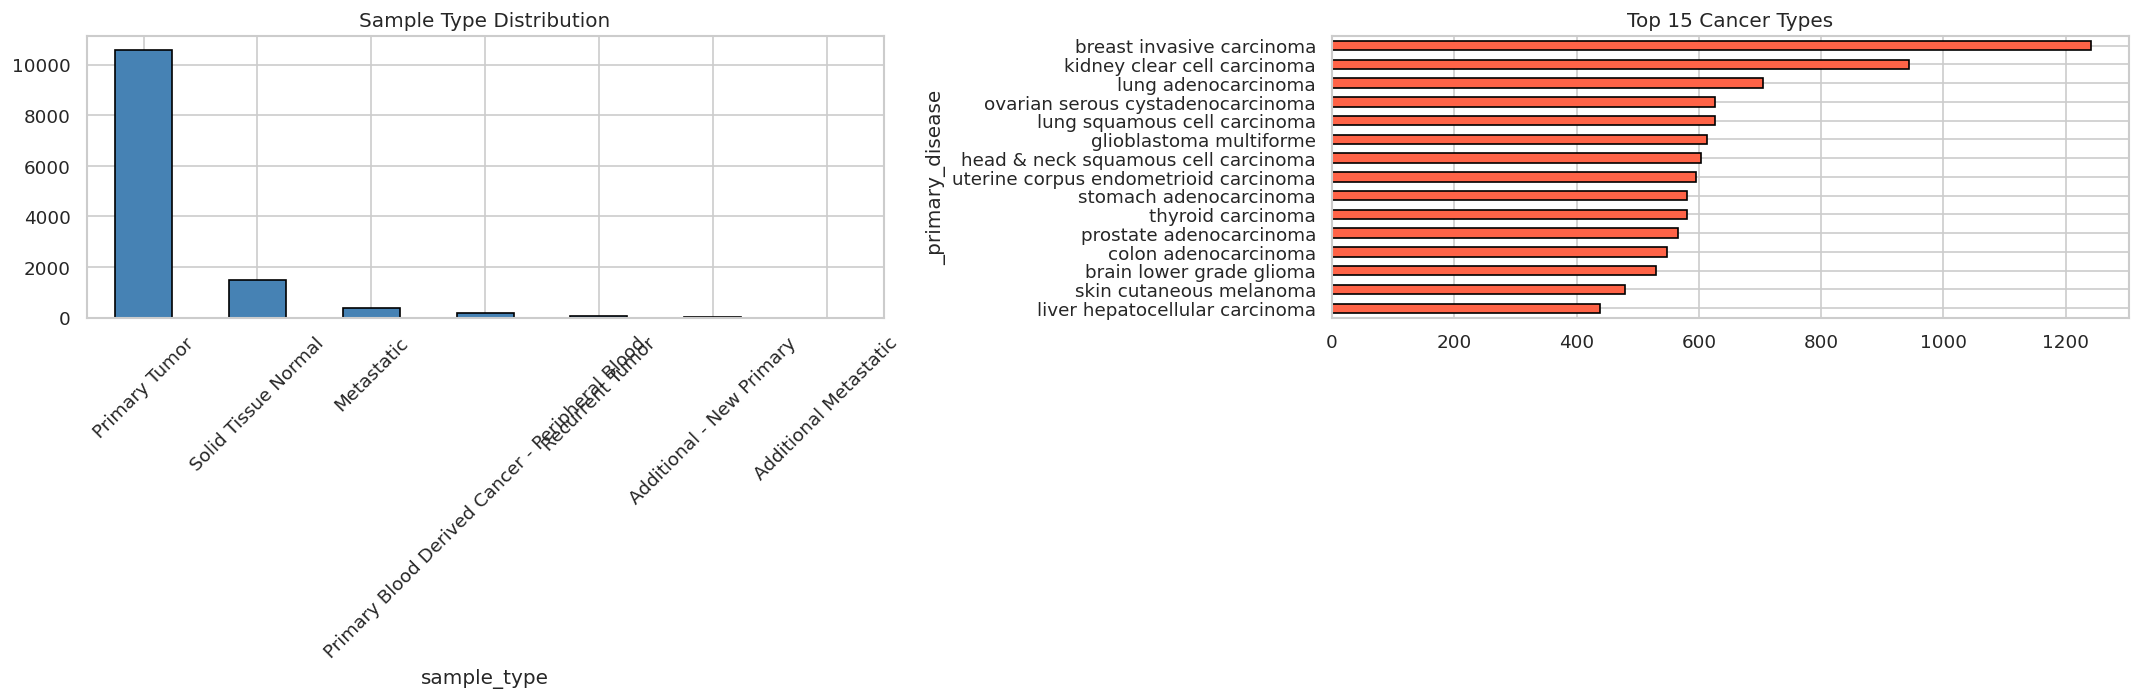

Primary Tumor patients: 10593
Cancer types (>=20 samples): 32


97

In [2]:
section('1. PHENOTYPE EDA & CLEANING')

pheno_raw = pd.read_csv(path_pheno, sep='\t')
print(f'Raw Phenotype Shape: {pheno_raw.shape}')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
pheno_raw['sample_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Sample Type Distribution'); axes[0].tick_params(axis='x', rotation=45)
pheno_raw['_primary_disease'].value_counts().head(15).plot(kind='barh', ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('Top 15 Cancer Types'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

pheno = pheno_raw[pheno_raw['sample_type'] == 'Primary Tumor'].copy()
pheno.index = pheno['sample'].str[:15]
pheno = pheno[~pheno.index.duplicated(keep='first')]
type_counts = pheno['_primary_disease'].value_counts()
valid_types = type_counts[type_counts >= 20].index
pheno = pheno[pheno['_primary_disease'].isin(valid_types)]
valid_patients_pheno = set(pheno.index)

print(f'Primary Tumor patients: {len(valid_patients_pheno)}')
print(f'Cancer types (>=20 samples): {pheno["_primary_disease"].nunique()}')
del pheno_raw; gc.collect()



  2. mRNA EDA & CLEANING
Loading mRNA...
Cleaned mRNA Shape: (11060, 20530)
Genes with any NaN: 4196 / 20530
Max NaN% per gene: 15.82%


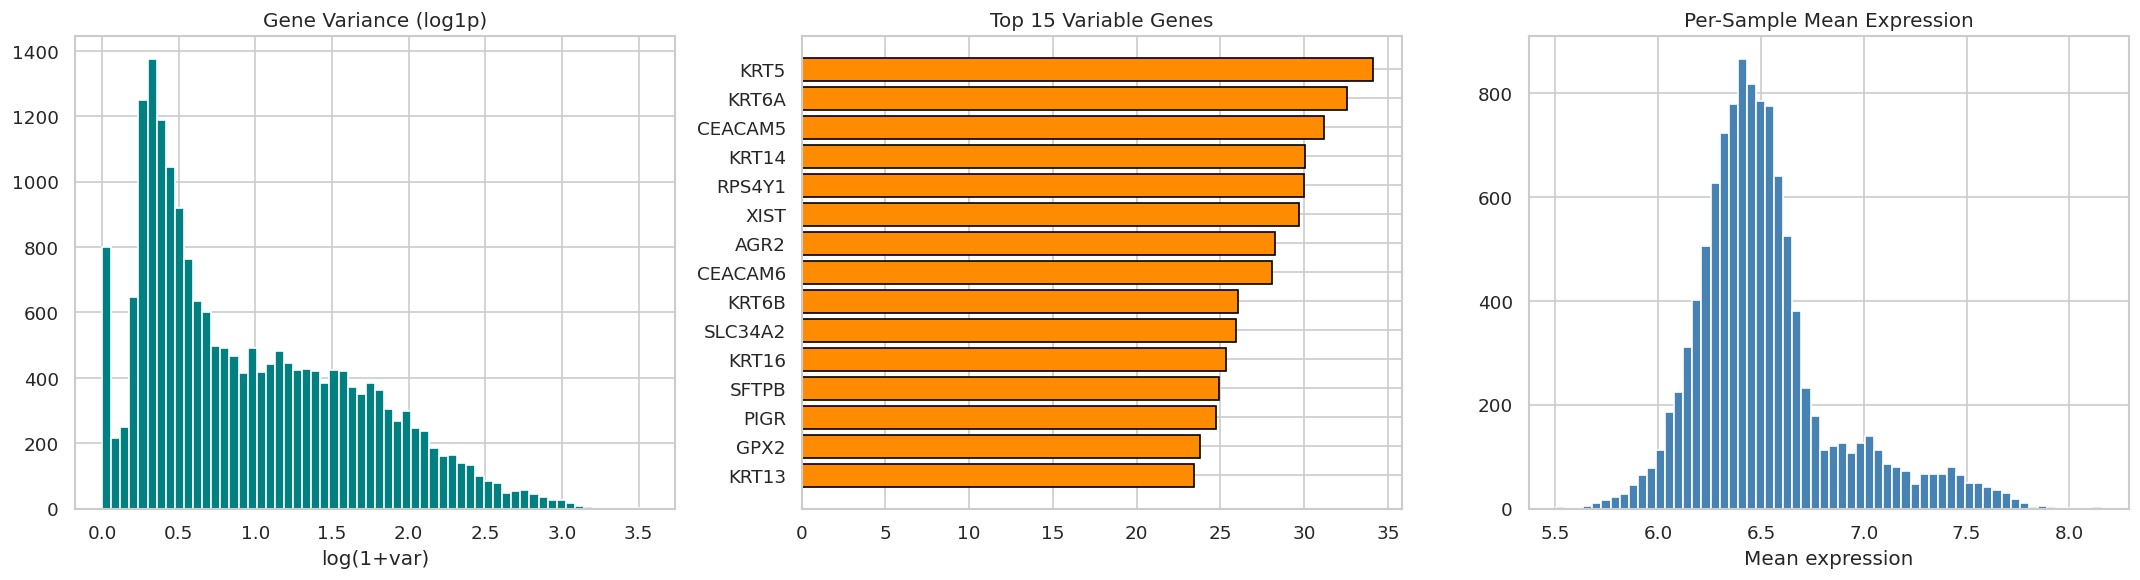

7632

In [3]:
section('2. mRNA EDA & CLEANING')

print('Loading mRNA...')
mrna = pd.read_csv(path_mrna, sep='\t', index_col=0).T
mrna.index = mrna.index.str[:15]
mrna = mrna[~mrna.index.duplicated(keep='first')]
mrna.columns = [str(c).split('|')[0] for c in mrna.columns]
mrna = mrna.loc[:, ~mrna.columns.duplicated(keep='first')]
print(f'Cleaned mRNA Shape: {mrna.shape}')

# EDA
gene_var = mrna.var(axis=0)
nan_pct  = mrna.isnull().mean(axis=0)
print(f'Genes with any NaN: {(nan_pct > 0).sum()} / {mrna.shape[1]}')
print(f'Max NaN% per gene: {nan_pct.max()*100:.2f}%')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(np.log1p(gene_var), bins=60, color='teal')
axes[0].set_title('Gene Variance (log1p)'); axes[0].set_xlabel('log(1+var)')
top15 = gene_var.nlargest(15)
axes[1].barh(top15.index, top15.values, color='darkorange', edgecolor='black')
axes[1].set_title('Top 15 Variable Genes'); axes[1].invert_yaxis()
axes[2].hist(mrna.mean(axis=1), bins=60, color='steelblue')
axes[2].set_title('Per-Sample Mean Expression'); axes[2].set_xlabel('Mean expression')
plt.tight_layout(); plt.show()

mrna = mrna.astype(np.float32)
valid_patients_mrna = set(mrna.index)
valid_genes_mrna    = set(mrna.columns)
gc.collect()



  3. CNV EDA & CLEANING
Loading CNV...
Cleaned CNV Shape: (10845, 23705)


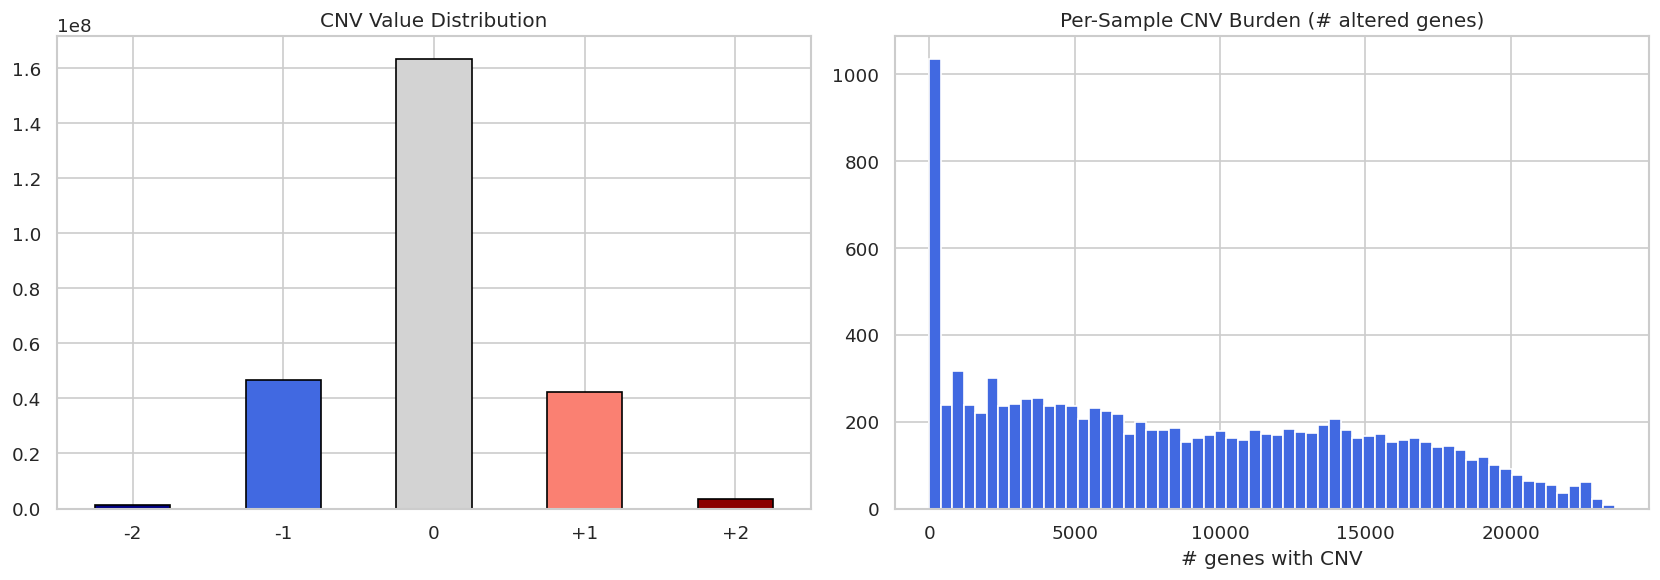

CNV missing values: 0 (filling with 0 = diploid normal)


16543

In [4]:
section('3. CNV EDA & CLEANING')

print('Loading CNV...')
cnv = pd.read_csv(path_cnv, sep='\t', index_col=0).T
cnv.index = cnv.index.str[:15]
cnv = cnv[~cnv.index.duplicated(keep='first')]
cnv.columns = [str(c).split('|')[0] for c in cnv.columns]
cnv = cnv.loc[:, ~cnv.columns.duplicated(keep='first')]
print(f'Cleaned CNV Shape: {cnv.shape}')

val_counts = cnv.stack().value_counts().sort_index()
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))
val_counts.plot(kind='bar', color=['navy','royalblue','lightgray','salmon','darkred'],
                edgecolor='black', ax=axes[0])
axes[0].set_title('CNV Value Distribution')
axes[0].set_xticklabels(['-2','-1','0','+1','+2'], rotation=0)

# Per-sample CNV burden
sample_cnv = (cnv != 0).sum(axis=1)
axes[1].hist(sample_cnv, bins=60, color='royalblue')
axes[1].set_title('Per-Sample CNV Burden (# altered genes)')
axes[1].set_xlabel('# genes with CNV')
plt.tight_layout(); plt.show()

print(f'CNV missing values: {cnv.isnull().sum().sum()} (filling with 0 = diploid normal)')
cnv = cnv.fillna(0).astype(np.int8)
valid_patients_cnv = set(cnv.index)
valid_genes_cnv    = set(cnv.columns)
gc.collect()



  4. MUTATION EDA & CLEANING
Loading Mutation...
Cleaned Mutation Shape: (9104, 40543)
Sparsity (fraction of zeros): 99.6%
Top mutated genes: {'TP53': 0.359182776801406, 'TTN': 0.3085456942003515, 'MUC16': 0.19859402460456943, 'CSMD3': 0.13334797891036906, 'PIK3CA': 0.1312609841827768}


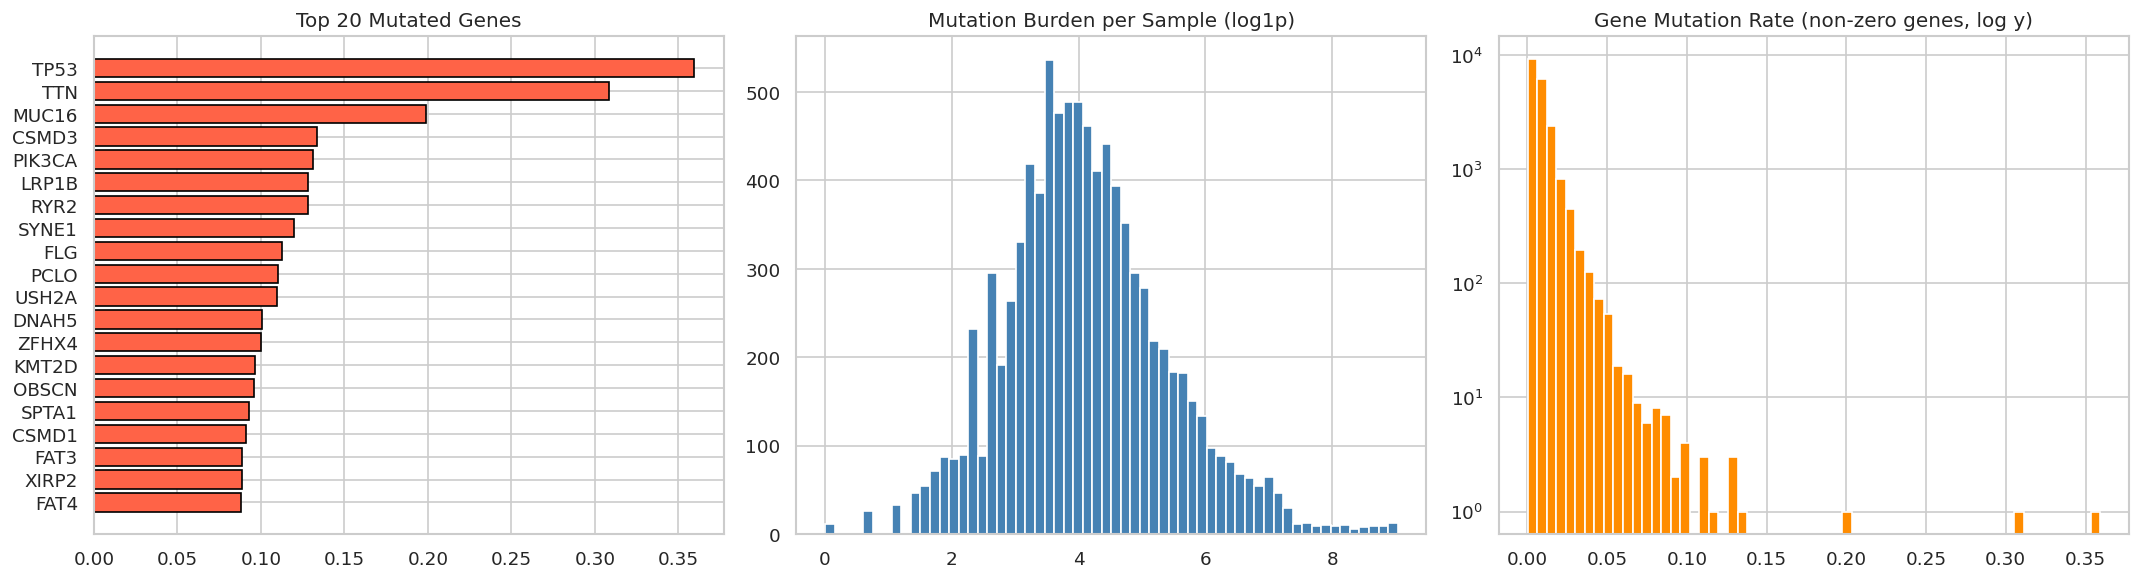

11626

In [5]:
section('4. MUTATION EDA & CLEANING')

print('Loading Mutation...')
mut = pd.read_csv(path_mut, sep='\t', index_col=0).T
mut.index = mut.index.str[:15]
mut = mut[~mut.index.duplicated(keep='first')]
mut.columns = [str(c).split('|')[0] for c in mut.columns]
mut = mut.loc[:, ~mut.columns.duplicated(keep='first')]
print(f'Cleaned Mutation Shape: {mut.shape}')

mut_rate     = mut.mean(axis=0)
sample_burden = mut.sum(axis=1)
sparsity     = (mut == 0).mean().mean()
print(f'Sparsity (fraction of zeros): {sparsity*100:.1f}%')
print(f'Top mutated genes: {mut_rate.nlargest(5).to_dict()}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top20 = mut_rate.nlargest(20)
axes[0].barh(top20.index, top20.values, color='tomato', edgecolor='black')
axes[0].set_title('Top 20 Mutated Genes'); axes[0].invert_yaxis()
axes[1].hist(np.log1p(sample_burden), bins=60, color='steelblue')
axes[1].set_title('Mutation Burden per Sample (log1p)')
axes[2].hist(mut_rate[mut_rate > 0], bins=60, color='darkorange', log=True)
axes[2].set_title('Gene Mutation Rate (non-zero genes, log y)')
plt.tight_layout(); plt.show()

mut = mut.fillna(0).astype(np.int8)
valid_patients_mut = set(mut.index)
valid_genes_mut    = set(mut.columns)
gc.collect()



  5. DNA METHYLATION EDA & CLEANING (27K Array)
Loading DNA Methylation (27K array)...
Note: this file is large (~1GB). Loading may take 2-3 minutes.
Raw methylation shape: (2728, 27578)
NaN per probe  — mean: 9.6%, max: 100.0%
NaN per sample — mean: 9.6%, max: 17.7%


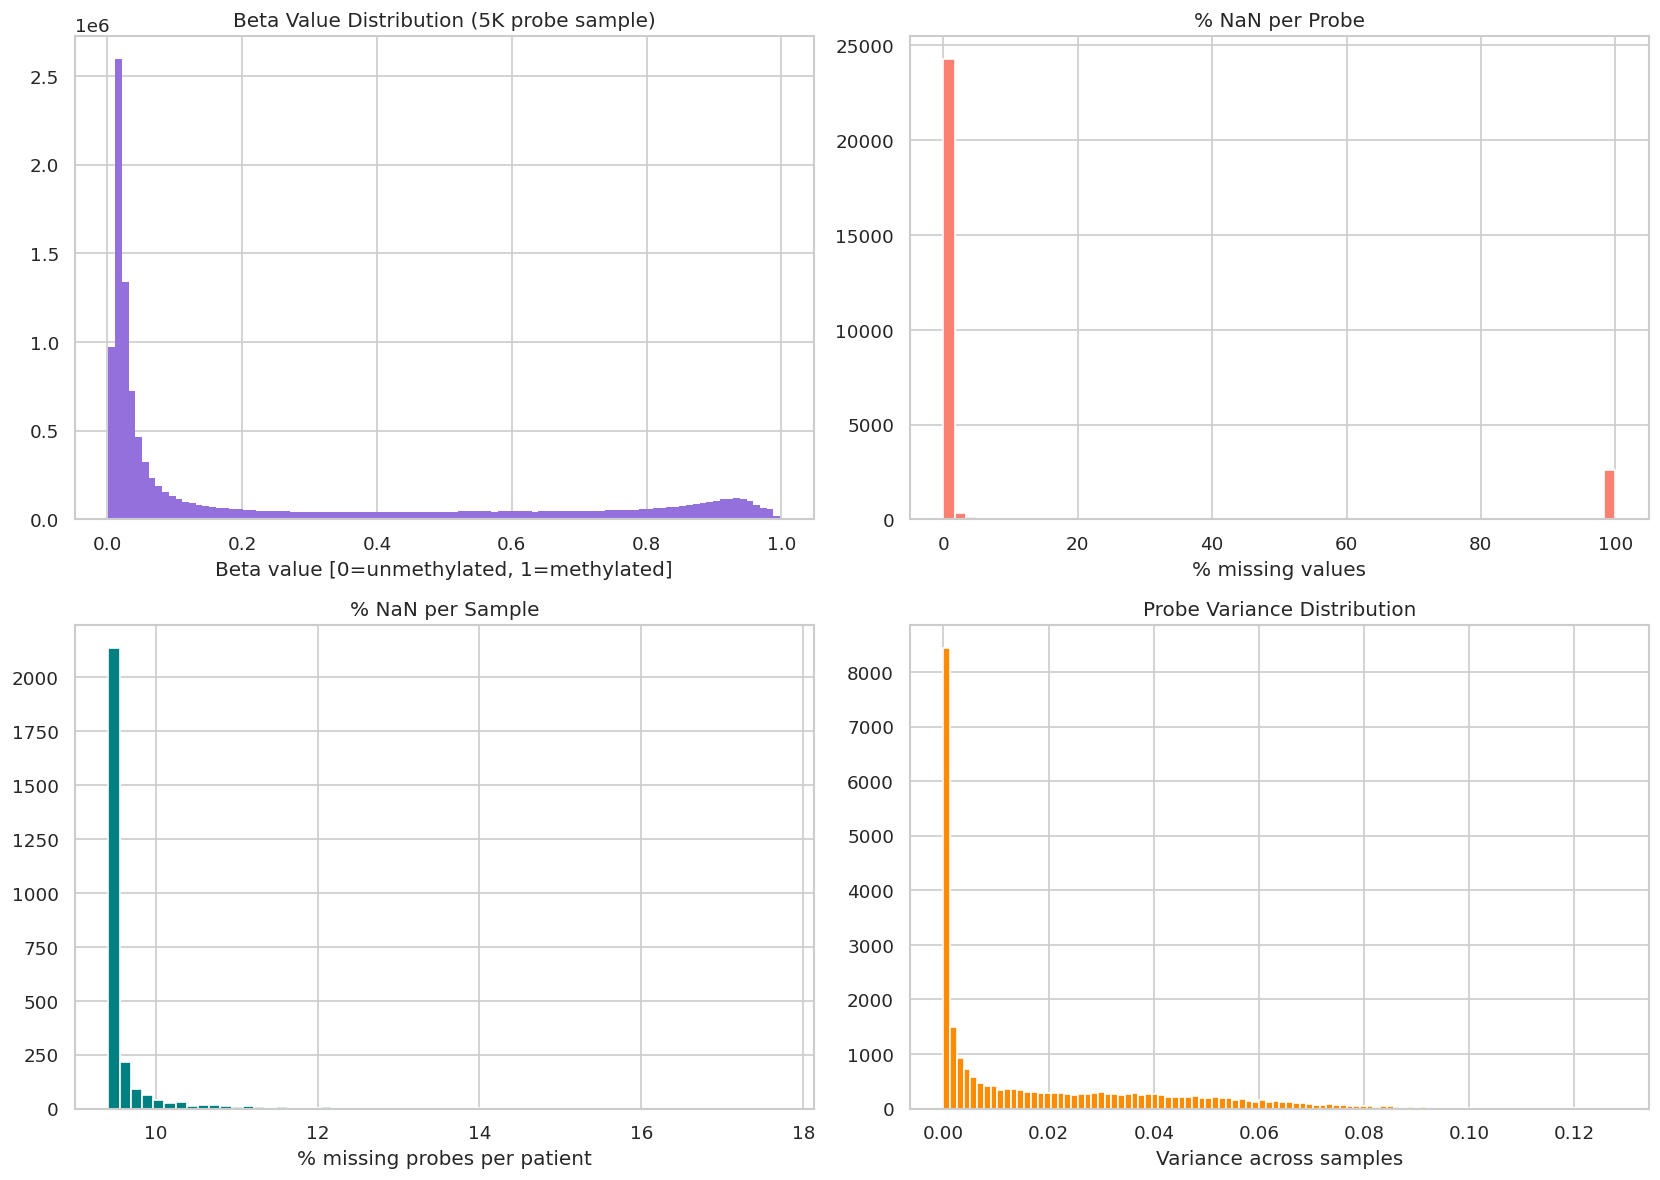

Dropped 2606 probes (>30% NaN). Remaining: 24972
Dropped 0 samples (>50% NaN). Remaining: 2728
Imputing missing values with probe-wise median...
NaN remaining after imputation: 0
Methylation ready: 2728 samples × 24972 probes


0

In [6]:
section('5. DNA METHYLATION EDA & CLEANING (27K Array)')

# ══════════════════════════════════════════════════════════════════════════════
#  DNA Methylation preprocessing — research-grade
#
#  Beta values: continuous in [0, 1]
#    0 = fully unmethylated, 1 = fully methylated
#    Bimodal distribution is expected and normal
#
#  Missing value strategy:
#  - WRONG: fill with 0 (means unmethylated — biologically meaningful, would
#    introduce systematic bias toward unmethylated state)
#  - WRONG: fill with mean (outliers pull mean toward wrong state for bimodal data)
#  - CORRECT: probe-wise MEDIAN (robust to outliers, standard for beta values,
#    used in most methylation array papers including Pathformer, TCGA analyses)
#
#  Reference: Pidsley et al. 2013 (Critical evaluation of DNA methylation
#  measurement using EPIC BeadChip), and TCGA methylation SOP.
#
#  When does probe-wise median fail?
#  - When a probe has >50% NaN — then even the median is unreliable.
#  - We drop such probes (threshold: max 30% NaN allowed).
# ══════════════════════════════════════════════════════════════════════════════

print('Loading DNA Methylation (27K array)...')
print('Note: this file is large (~1GB). Loading may take 2-3 minutes.')

try:
    meth = pd.read_csv(path_meth, sep='\t', index_col=0).T
    meth.index = meth.index.str[:15]
    meth = meth[~meth.index.duplicated(keep='first')]
    meth = meth.loc[:, ~meth.columns.duplicated(keep='first')]
    meth = meth.astype(np.float32)
    print(f'Raw methylation shape: {meth.shape}')

    # ── Missing value analysis ────────────────────────────────────────────────
    nan_per_probe  = meth.isnull().mean(axis=0)
    nan_per_sample = meth.isnull().mean(axis=1)

    print(f'NaN per probe  — mean: {nan_per_probe.mean()*100:.1f}%, max: {nan_per_probe.max()*100:.1f}%')
    print(f'NaN per sample — mean: {nan_per_sample.mean()*100:.1f}%, max: {nan_per_sample.max()*100:.1f}%')

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    # Beta value distribution (sample of probes)
    sample_probes = np.random.choice(meth.columns, size=min(5000, len(meth.columns)), replace=False)
    vals = meth[sample_probes].values.flatten()
    vals = vals[~np.isnan(vals)]
    axes[0,0].hist(vals, bins=100, color='mediumpurple', edgecolor='none')
    axes[0,0].set_title('Beta Value Distribution (5K probe sample)')
    axes[0,0].set_xlabel('Beta value [0=unmethylated, 1=methylated]')

    axes[0,1].hist(nan_per_probe * 100, bins=60, color='salmon')
    axes[0,1].set_title('% NaN per Probe')
    axes[0,1].set_xlabel('% missing values')

    axes[1,0].hist(nan_per_sample * 100, bins=60, color='teal')
    axes[1,0].set_title('% NaN per Sample')
    axes[1,0].set_xlabel('% missing probes per patient')

    # Probe variance distribution
    probe_var = meth.var(axis=0)
    axes[1,1].hist(probe_var, bins=100, color='darkorange')
    axes[1,1].set_title('Probe Variance Distribution')
    axes[1,1].set_xlabel('Variance across samples')
    plt.tight_layout(); plt.show()

    # ── Drop high-NaN probes (>30% missing) ──────────────────────────────────
    keep_probes = nan_per_probe[nan_per_probe <= 0.30].index
    n_dropped_probes = len(meth.columns) - len(keep_probes)
    meth = meth[keep_probes]
    print(f'Dropped {n_dropped_probes} probes (>30% NaN). Remaining: {meth.shape[1]}')

    # ── Drop samples with >50% NaN (unusable) ────────────────────────────────
    nan_per_sample_after = meth.isnull().mean(axis=1)
    keep_samples = nan_per_sample_after[nan_per_sample_after <= 0.50].index
    n_dropped_samples = len(meth) - len(keep_samples)
    meth = meth.loc[keep_samples]
    print(f'Dropped {n_dropped_samples} samples (>50% NaN). Remaining: {meth.shape[0]}')

    # ── Probe-wise median imputation ──────────────────────────────────────────
    print('Imputing missing values with probe-wise median...')
    probe_medians = meth.median(axis=0)
    meth = meth.fillna(probe_medians)
    print(f'NaN remaining after imputation: {meth.isnull().sum().sum()}')

    valid_patients_meth = set(meth.index)
    valid_probes_meth   = set(meth.columns)
    print(f'Methylation ready: {meth.shape[0]} samples × {meth.shape[1]} probes')
    METH_LOADED = True

except FileNotFoundError:
    print('WARNING: Methylation file not found. Continuing without methylation.')
    print(f'Expected path: {path_meth}')
    print('To add methylation: download HumanMethylation27 from TCGA Xena hub (link in screenshot)')
    valid_patients_meth = set()
    METH_LOADED = False
    INCLUDE_METHYLATION = False

gc.collect()



  5. ALIGNMENT & PREPROCESSING
Including methylation in intersection
Common patients: 596
Common genes (mRNA∩CNV∩Mut): 18046

Imputing mRNA NaN with gene-wise mean (train/val/test split done in model code)...
Removing bottom 10% lowest-variance genes...

--- FINAL ALIGNED SHAPES ---
mRNA:   (596, 16241)
CNV:    (596, 16241)
Mut:    (596, 16241)
Meth:   (596, 24972)
Labels: (596, 1)


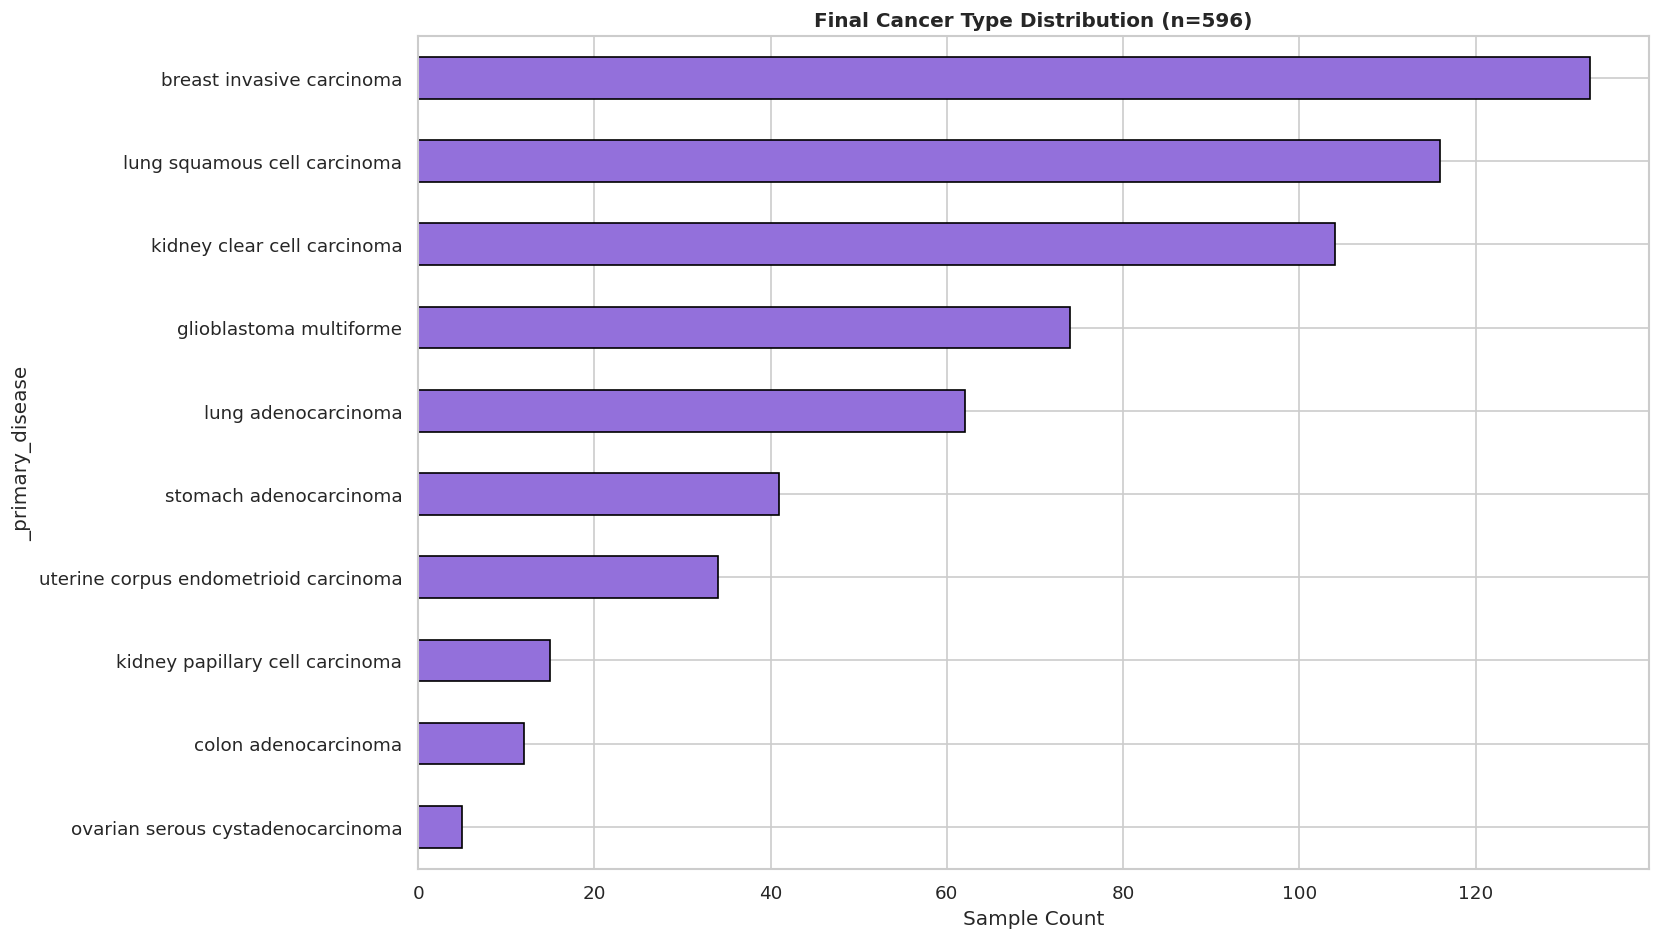

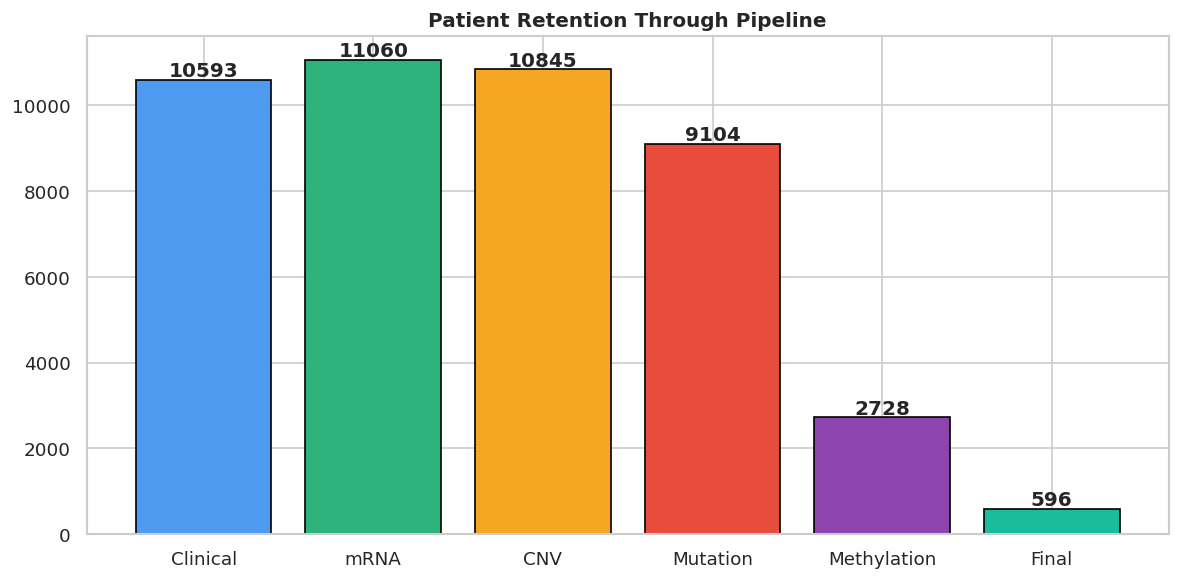

3723

In [7]:
section('5. ALIGNMENT & PREPROCESSING')

# Build patient intersection
base_sets = [valid_patients_pheno, valid_patients_mrna, valid_patients_cnv, valid_patients_mut]
base_names = ['Phenotype', 'mRNA', 'CNV', 'Mutation']

if INCLUDE_METHYLATION and METH_LOADED:
    base_sets.append(valid_patients_meth)
    base_names.append('Methylation')
    print('Including methylation in intersection')
else:
    print('Excluding methylation (3-modality pipeline)')

common_patients = sorted(set.intersection(*base_sets))
print(f'Common patients: {len(common_patients)}')

# Gene intersection (only mRNA/CNV/Mut share gene space)
common_genes = sorted(valid_genes_mrna & valid_genes_cnv & valid_genes_mut)
print(f'Common genes (mRNA∩CNV∩Mut): {len(common_genes)}')

# Slice all matrices
mrna   = mrna.loc[common_patients, common_genes]
cnv    = cnv.loc[common_patients, common_genes]
mut    = mut.loc[common_patients, common_genes]
labels = pheno.loc[common_patients, ['_primary_disease']]

if INCLUDE_METHYLATION and METH_LOADED:
    meth = meth.loc[common_patients]   # probes don't need to match gene space

# ── Preprocessing ──────────────────────────────────────────────────────────
print('\nImputing mRNA NaN with gene-wise mean (train/val/test split done in model code)...')
mrna = mrna.fillna(mrna.mean(axis=0))

print('Removing bottom 10% lowest-variance genes...')
gene_var = mrna.var(axis=0)
keep_genes = gene_var[gene_var > gene_var.quantile(0.10)].index
mrna = mrna[keep_genes].astype(np.float32)
cnv  = cnv[keep_genes]
mut  = mut[keep_genes]

print('\n--- FINAL ALIGNED SHAPES ---')
print(f'mRNA:   {mrna.shape}')
print(f'CNV:    {cnv.shape}')
print(f'Mut:    {mut.shape}')
if INCLUDE_METHYLATION and METH_LOADED:
    print(f'Meth:   {meth.shape}')
print(f'Labels: {labels.shape}')

# Class distribution plot
fig, ax = plt.subplots(figsize=(14, 8))
class_counts = labels['_primary_disease'].value_counts()
class_counts.plot(kind='barh', ax=ax, color='mediumpurple', edgecolor='black')
ax.set_title(f'Final Cancer Type Distribution (n={len(common_patients)})', fontweight='bold')
ax.set_xlabel('Sample Count'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

# Patient retention waterfall
retention = {'Clinical': len(valid_patients_pheno), 'mRNA': len(valid_patients_mrna),
             'CNV': len(valid_patients_cnv), 'Mutation': len(valid_patients_mut)}
if INCLUDE_METHYLATION and METH_LOADED:
    retention['Methylation'] = len(valid_patients_meth)
retention['Final'] = len(common_patients)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4e9af1','#2db37b','#f5a623','#e74c3c','#8e44ad','#1abc9c','#2c3e50']
ax.bar(list(retention.keys()), list(retention.values()), color=colors[:len(retention)], edgecolor='black')
ax.set_title('Patient Retention Through Pipeline', fontweight='bold')
for i, v in enumerate(retention.values()):
    ax.text(i, v + 80, str(v), ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

gc.collect()


In [8]:
section('6. SAVING OUTPUT FILES')

# Ensure string columns
mrna.columns = mrna.columns.astype(str)
cnv.columns  = cnv.columns.astype(str)
mut.columns  = mut.columns.astype(str)

print('Saving 3-modality files (parquet)...')
mrna.to_parquet('mrna_final.parquet')
cnv.to_parquet('cnv_final.parquet')
mut.to_parquet('mut_final.parquet')
labels.to_parquet('labels_final.parquet')

if INCLUDE_METHYLATION and METH_LOADED:
    print('Saving methylation file (parquet)...')
    meth.columns = meth.columns.astype(str)
    meth.to_parquet('meth_final.parquet')
    print('  meth_final.parquet saved')

print('\nSummary of saved files:')
print(f'  mrna_final.parquet  — {mrna.shape}')
print(f'  cnv_final.parquet   — {cnv.shape}')
print(f'  mut_final.parquet   — {mut.shape}')
if INCLUDE_METHYLATION and METH_LOADED:
    print(f'  meth_final.parquet  — {meth.shape}')
print(f'  labels_final.parquet— {labels.shape}')
print('\nAll files ready for OncoBridge-MMCAT v6!')
print()
print('To use methylation in training:')
print('  1. Upload meth_final.parquet to your Kaggle dataset')
print('  2. In training notebook CONFIG: active_modalities=["mrna","cnv","mut","meth"]')
print('  3. Check meth_path points to correct location')



  6. SAVING OUTPUT FILES
Saving 3-modality files (parquet)...
Saving methylation file (parquet)...
  meth_final.parquet saved

Summary of saved files:
  mrna_final.parquet  — (596, 16241)
  cnv_final.parquet   — (596, 16241)
  mut_final.parquet   — (596, 16241)
  meth_final.parquet  — (596, 24972)
  labels_final.parquet— (596, 1)

All files ready for OncoBridge-MMCAT v6!

To use methylation in training:
  1. Upload meth_final.parquet to your Kaggle dataset
  2. In training notebook CONFIG: active_modalities=["mrna","cnv","mut","meth"]
  3. Check meth_path points to correct location
